# **Support Vector Machines**

**Does a Hyperplane exist that can effectively separated classes?**

## **What Is a Hyperplane?**

A **hyperplane** is a flat decision boundary that separates the feature space.

In an N-dimensional feature space, a hyperplane is an affine subspace of dimension N–1.

Examples:

- 1D → hyperplane = a point
- 2D → hyperplane = a line
- 3D → hyperplane = a plane

## **Hyperplanes for Classification**

**Goal:** Use a hyperplane to separate classes so that new data points fall on one side or the other.

**Example:**
  - Suppose we want to classify emails as:spam and not spam
  - If we use two features: number of links and email length
  - Then the classifier may draw a **line** separating spam from non-spam emails.
  - That line is the hyperplane.



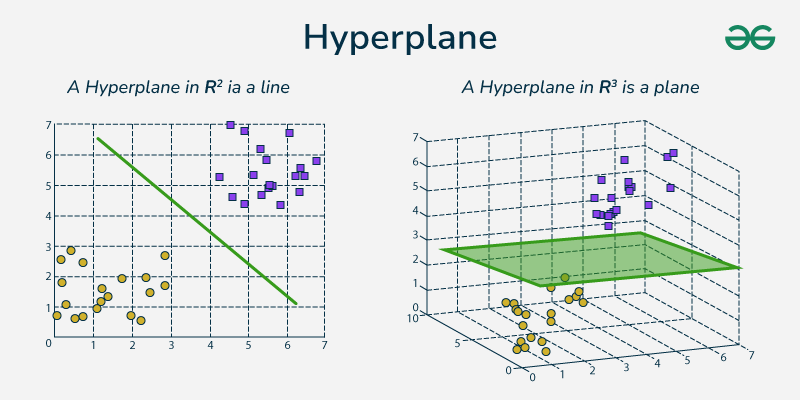


## **Brief History of Support Vector Machines**

Support Vector Machines were developed gradually starting in the 1960s, mainly through the work of Vladimir Vapnik.

Early research introduced the idea of margin-based classifiers for pattern recognition.

In the 1990s, SVM evolved into the modern algorithm with two key improvements:

- **Soft margins**, allowing some misclassification for noisy data
- The **kernel trick**, enabling nonlinear decision boundaries

Soon after, the method was extended to regression, known as **Support Vector Regression (SVR)**.

Today, SVM is widely used for **classification and regression**, especially in high-dimensional datasets.

##**Maximum Margin Classifier**

- Used when classes are **perfectly separable**.

- Many hyperplanes might separate the classes → choose the one that **maximizes the margin**.

- **Margin:** distance between the hyperplane and the closest data points from each class.

- The best hyperplane is the one that **maximizes this margin**.

- Why maximize the margin? Because larger margins usually lead to **better generalization** on unseen data.

- The points that lie on the margin are the **supporting vectors** that determine the hyperplane.

- These points are critical because they **define the decision boundary**.

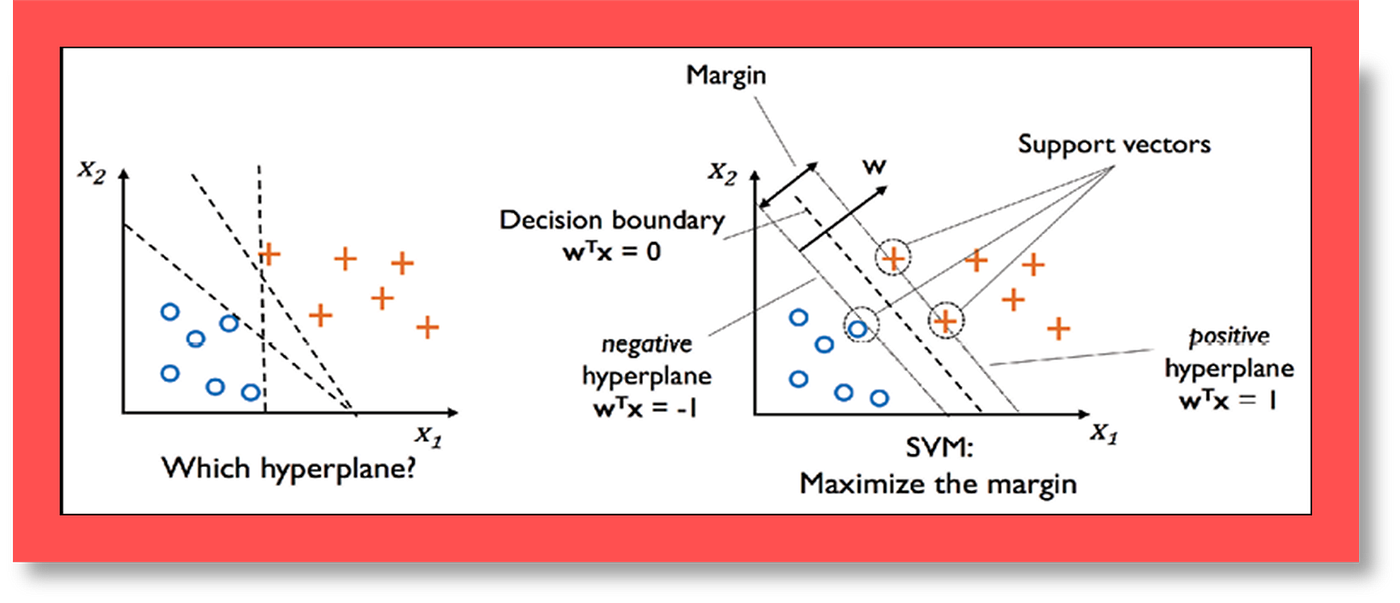

##**Support Vector Classifier (Soft Margin)**

When classes are **not perfectly separable**:

- We introduce **soft margins**, allowing some points to fall **inside** the margin or be **misclassified**.

- A parameter **C** controls how many misclassifications are allowed:

    - High C → narrower margin, fewer misclassifications (**low bias, high variance**) → risk of overfitting
    - Low C → wider margin, more misclassifications allowed (**higher bias, lower variance**) → better generalization

- We choose C using **cross-validation**.

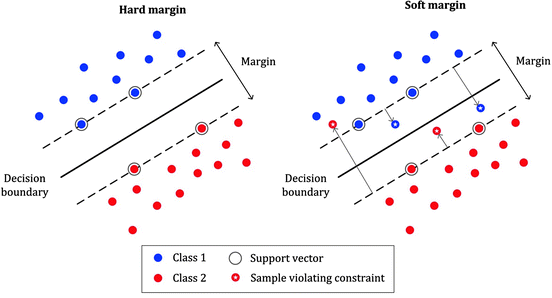

##**When Hyperplanes Fail**

If the classes cannot be separated (even with soft margins), e.g.:

- circular patterns
- concentric groups
- complex nonlinear boundaries

Then linear separation is insufficient.

In this case we move from Support vector Classifier to **Support Vector Machines**.

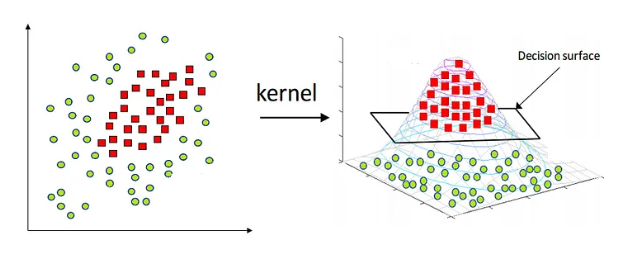

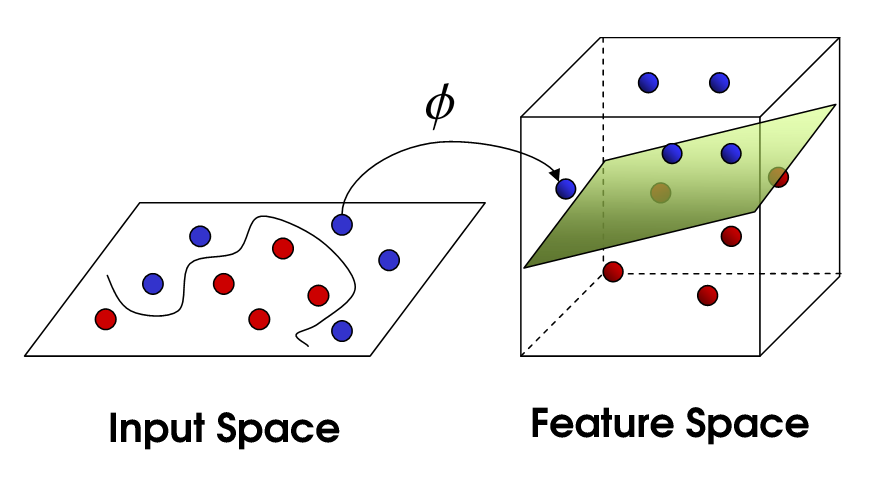

##**Support Vector Machines (SVMs) and the Kernel Trick**

SVMs use **kernels** to project data into a **higher-dimensional space** where a linear hyperplane does work.

Example:

- Project x → x² (polynomial kernel)

- In the new space, data becomes linearly separable.

#**Kernel Trick**

- Instead of explicitly computing transformed coordinates, SVM uses **similarity between points (dot products between vectors)** using a kernel function.

- This is the kernel trick.

- Kernels include:
     - Polynomial
     - RBF (Gaussian)
     - Sigmoid
     - Linear (degenerate kernel)


# **Mathematical Summary**

### **Hyperplane equation:**

In a two–dimensional feature space with features $x_1$ and $x_2$, a hyperplane (a line in 2D) can be written as

$$
\beta_0 + \beta_1 x_1 + \beta_2 x_2 = 0
$$

More generally, for $p$ features:

$$
\beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p = 0
$$


Where:

- $x = (x_1, x_2, ..., x_p)$ is the feature vector  
- $\beta = (\beta_1, \beta_2, ..., \beta_p)$ are the coefficients  
- $\beta_0$ is the intercept  

<br>

### **Separating Hyperplanes:**

The hyperplane $\beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p = 0$ separates the feature space into two regions.

$$ y = \beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p$$

- Points with $ \beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p > 0$ are classified as class +1

- Points with $ \beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p < 0$ are classified as class -1


These expressions determine **which side of the hyperplane a point lies on**.

<br>

**Using $y_i$ to unify the rule:**

Instead of writing two separate conditions, we multiply the decision function by the class label:

$$y_i \in \{-1, +1\}$$

Correct classification occurs when:

$$y_i(\beta_0 + \beta_1 x_{i1} + \cdots + \beta_p x_{ip}) > 0$$

This single inequality ensures:

- If $y_i = +1$, the expression inside must be **positive**.
- If $y_i = -1$, the expression inside must be **negative**.

So $y_i$ simply **encodes the class label** and allows us to write **one condition instead of two**.



### **Data:**

We must also specify how the dataset is represented.

Assume we have:

- $n$ observations (data points)
- $p$ features for each observation

Each observation can be written as a feature vector:

$$ x_i = (x_{i1}, x_{i2}, \dots, x_{ip})$$

where:

- $i = 1,2,\dots,n$ indexes the observations  
- $j = 1,2,\dots,p$ indexes the features  

The entire dataset can be written as a matrix $X$.

In the mathematical formulation used for SVMs, the dataset is often written as the **transposed feature matrix**:

$$
X =
\begin{bmatrix}
x_{11} & x_{21} & \cdots & x_{n1} \\
x_{12} & x_{22} & \cdots & x_{n2} \\
\vdots & \vdots & \ddots & \vdots \\
x_{1p} & x_{2p} & \cdots & x_{np}
\end{bmatrix}
$$


This layout is the transpose of the format commonly used in tools such as data frames, where observations typically appear as rows and features as columns. The information is the same; only the orientation of the matrix differs.

### **Maximum Margin Classifier (Hard Margin):**

The goal of a maximum margin classifier is to find the hyperplane that **maximizes the margin $M$** between the two classes.

The optimization problem is:

$$\max_{\beta_0,\beta_1,\dots,\beta_P,M} M$$

subject to

 $$y_i(\beta_0 + \beta_1 x_{i1} + \beta_1 x_{i2} + \cdots + \beta_p x_{ip} ) \ge M$$

  for $i = 1,2,\dots,n$

and

 $$\sum_{j=1}^{p} \beta_j^2 = 1$$

  Where:

  - $x_i$ = feature vector for observation \(i\)
  - $y_i \in \{-1,1\}$ = class label
  - $M$ = margin


<br>

The constraint $\sum_{j=1}^{p} \beta_j^2 = 1$ ensures that the expression
$y_i(\beta_0 + \beta^T x_i)$ represents the **orthogonal distance from the point to the hyperplane**.

This formulation guarantees that **no points lie inside the margin**.


### **Support Vector Classifier (Soft Margin)**

Real datasets usually contain noise or overlapping classes.  
A support vector classifier allows **some points to violate the margin**.

We introduce slack variables $ \epsilon_i $.

The optimization becomes:

$$\max_{\beta_0,\beta,M,\epsilon} M$$

subject to

$$y_i(\beta_0 + \beta^T x_i) \ge M(1-\epsilon_i)$$

$\epsilon_i \ge 0$

and

$$\sum_{i=1}^{n} \epsilon_i \le C$$

Where:

- $ \epsilon_i $ error factor, measures the margin violation
- $C$ controls the **total amount of misclassification allowed**

Interpretation:

- Larger $C$ → allows **more violations**
- Smaller $C$ → allows **fewer violations**

As $C \to 0$, the model approaches a **maximum margin classifier**.

<br>

Note: In **scikit-learn**, the parameter $C$ is defined as a **regularization parameter inversely proportional to the $C$ shown in these equations**.


### **Support Vector Machine (Feature Expansion)**

If the data is **not linearly separable**, we transform the feature space.

Example: polynomial expansion

Original features: $x_1, x_2, \dots, x_p$

Expanded features: $x_1, x_1^2, x_2, x_2^2, \dots, x_p, x_p^2$

The classifier becomes

$$\beta_0 + \sum_{j=1}^{p} \beta_j x_j + \sum_{j=1}^{p} \beta_j^* x_j^2$$

We still maximize the margin while allowing violations:

$$y_i f(x_i) \ge M(1-\epsilon_i)$$

with

$$\sum \epsilon_i \le C$$



<br>

How to deal with very large feature space?


### **Kernel trick  (Dot Product, Inner Product)**

*The mathematical formulation is beyond our scope!*

Intuitively:
- The inner product act as a measure of similarity between vectors.
- The use of kernels can be thought of as a measure of similarity between the original feature space and the enlarged feature space.


<br><br><br>

## **SVM with Scitkit-Learn**

**NOTE: For this example, we will explore the algorithm, so we'll skip scaling and also skip a train\test split and instead see how the various parameters can change an SVM (easiest to visualize the effects in classification)**

### **Data**

The data shown here simulates a medical study in which mice infected with a virus were given various doses of two medicines and then checked 2 weeks later to see if they were still infected. Given this data, our goal is to create a classifcation model than predict (given two dosage measurements) if they mouse will still be infected with the virus.

You will notice the groups are very separable, this is on purpose, to explore how the various parameters of an SVM model behave.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("mouse_viral_study.csv")
df.head()

,Med_1_mL,Med_2_mL,Virus Present
0,6.508231,8.582531,0
1,4.126116,3.073459,1
2,6.427870,6.369758,0
3,3.672953,4.905215,1
4,1.580321,2.440562,1


In [ ]:
df.columns

Index(['Med_1_mL', 'Med_2_mL', 'Virus Present'], dtype='object')

<Axes: xlabel='Med_1_mL', ylabel='Med_2_mL'>

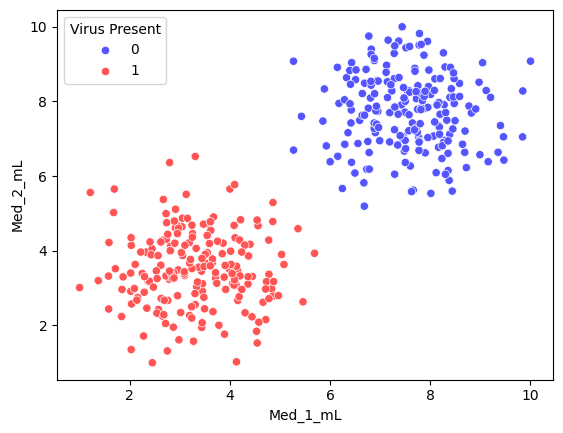

In [ ]:
sns.scatterplot(x='Med_1_mL',y='Med_2_mL',hue='Virus Present',data=df,palette='seismic')

### **Separating Hyperplane**

Our goal with SVM is to create the best separating hyperplane. In 2 dimensions, this is simply a line.

Let's first approximately and manually create a separating line.

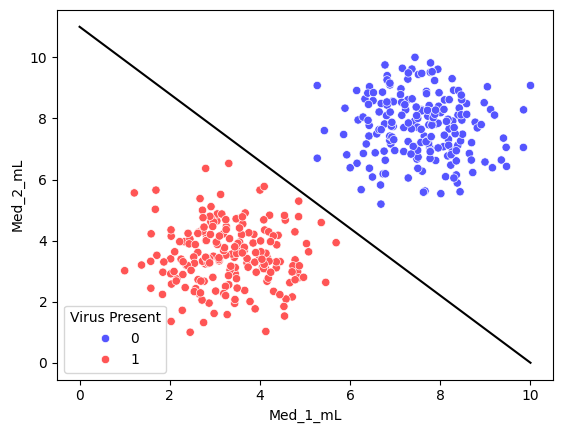

In [ ]:
sns.scatterplot(x='Med_1_mL',y='Med_2_mL',hue='Virus Present',palette='seismic',data=df)

x = np.linspace(0,10,100)
m = -1.1
b = 11
y = m*x + b
plt.plot(x,y,'k')

## **SVM - Support Vector Machine**

Now let's explore how SVM can find the best slope and intercept for this line.

In [ ]:
from sklearn.svm import SVC # Supprt Vector Classifier

In [ ]:
help(SVC)

Help on class SVC in module sklearn.svm._classes:

class SVC(sklearn.svm._base.BaseSVC)
 |  SVC(*, C=1.0, kernel='rbf', degree=3, gamma='scale', coef0=0.0, shrinking=True, probability=False, tol=0.001, cache_size=200, class_weight=None, verbose=False, max_iter=-1, decision_function_shape='ovr', break_ties=False, random_state=None)
 |
 |  C-Support Vector Classification.
 |
 |  The implementation is based on libsvm. The fit time scales at least
 |  quadratically with the number of samples and may be impractical
 |  beyond tens of thousands of samples. For large datasets
 |  consider using :class:`~sklearn.svm.LinearSVC` or
 |  :class:`~sklearn.linear_model.SGDClassifier` instead, possibly after a
 |  :class:`~sklearn.kernel_approximation.Nystroem` transformer or
 |  other :ref:`kernel_approximation`.
 |
 |  The multiclass support is handled according to a one-vs-one scheme.
 |
 |  For details on the precise mathematical formulation of the provided
 |  kernel functions and how `gamma`, `

**NOTE: For this example, we will explore the algorithm, so we'll skip any scaling or even a train\test split for now**

In [ ]:
y = df['Virus Present']
X = df.drop('Virus Present',axis=1)

In [ ]:
model = SVC(kernel='linear', C=100)
model.fit(X, y)

SVC(C=100, kernel='linear')

**NOTE: The C parameter is a regularization parameter that allow for misclassifications. It's actually inversely proportional to the C value shown in the equations.**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


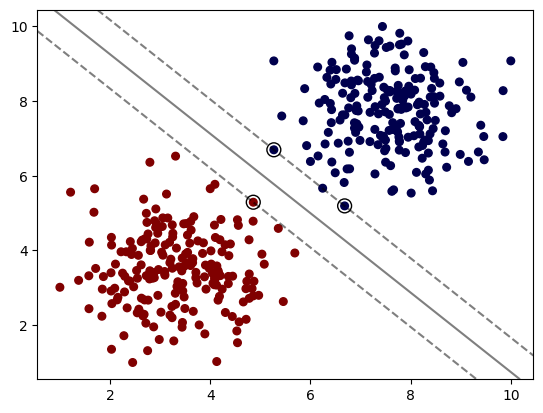

In [ ]:
# Download svm_margin_plot.py and place it in the same folder
# https://scikit-learn.org/stable/auto_examples/svm/plot_separating_hyperplane.html
from svm_margin_plot import plot_svm_boundary

plot_svm_boundary(model,X,y)

## **Hyper Parameters**

### **C**

Regularization parameter. The strength of the regularization is **inversely** proportional to C. Must be strictly positive. The penalty is a squared l2 penalty.

*Note: If you are following along with the equations, C in scikit-learn is **inversely** proportional to this value.*

In [ ]:
model = SVC(kernel='linear', C=0.05)
model.fit(X, y)

SVC(C=0.05, kernel='linear')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


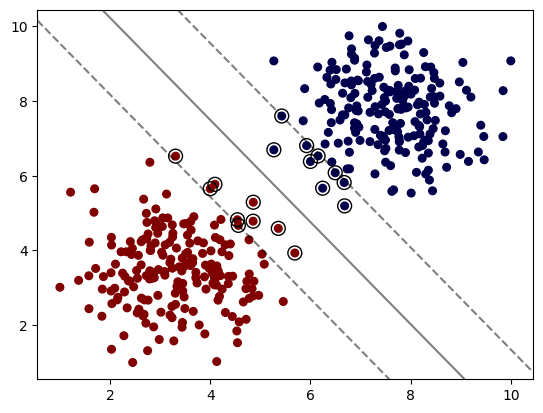

In [ ]:
plot_svm_boundary(model,X,y)

### **Kernel**

[Choosing a Kernel](https://stats.stackexchange.com/questions/18030/how-to-select-kernel-for-svm?rq=1)

- The default kernel for the svm.SVC class in scikit-learn is the Radial Basis Function (RBF)

#### **rbf** - [Radial Basis Function](https://en.wikipedia.org/wiki/Radial_basis_function_kernel)


When training an SVM with the Radial Basis Function (RBF) kernel, two parameters must be considered: C and gamma.

- The parameter C, common to all SVM kernels, trades off misclassification of training examples against simplicity of the decision surface. A low C makes the decision surface smooth, while a high C aims at classifying all training examples correctly.

- The gamma defines how much influence a single training example has. The larger gamma is, the closer other examples must be to be affected.

  (options: 'scale': 1/(n_features * X.var()), 'auto': 1/n_features, a float number)

In [ ]:
model = SVC(kernel='rbf', C=1)
model.fit(X, y)

SVC(C=1)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


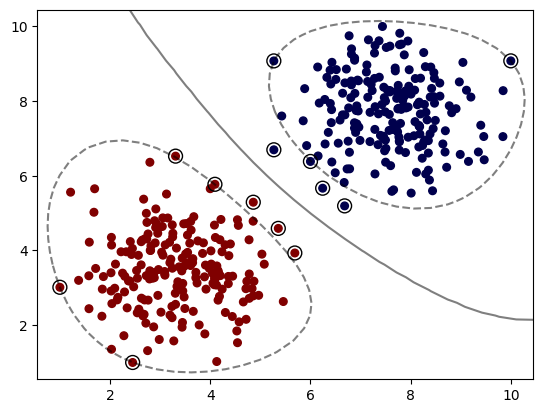

In [ ]:
plot_svm_boundary(model,X,y)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


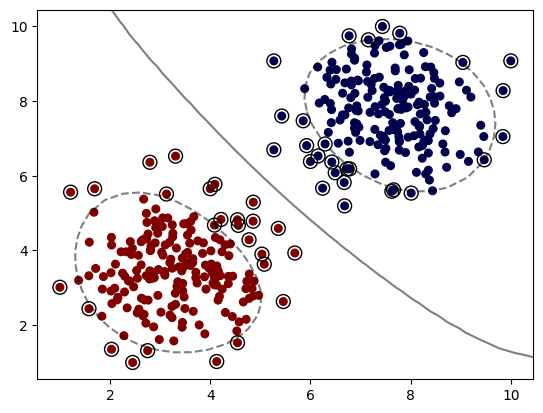

In [ ]:
model = SVC(kernel='rbf', C=0.1)
model.fit(X, y)
plot_svm_boundary(model,X,y)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


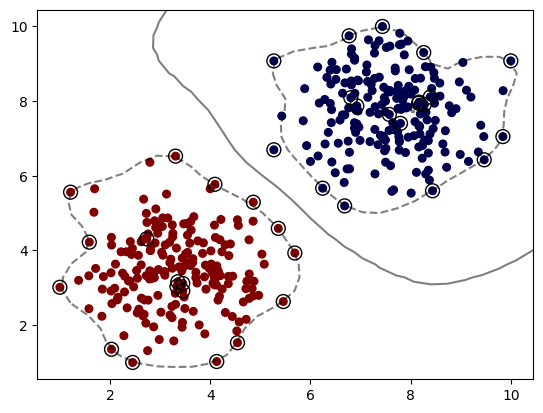

In [ ]:
model = SVC(kernel='rbf', C=1, gamma= 'auto')
model.fit(X, y)
plot_svm_boundary(model,X,y)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


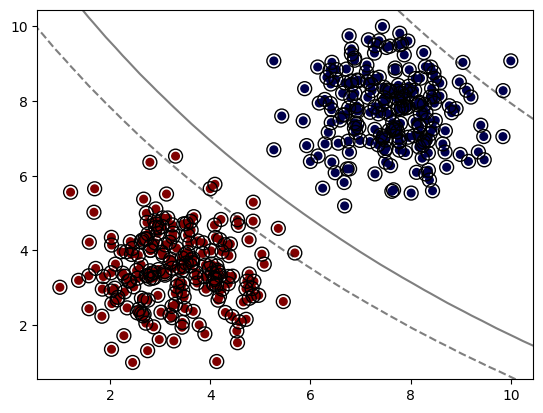

In [ ]:
model = SVC(kernel='sigmoid')
model.fit(X, y)
plot_svm_boundary(model,X,y)

Notice almost all the blue points are used for support vector, so perhaps the sigmoid kernel is not a good choice here!

#### **Degree (poly kernels only)**

Degree of the polynomial kernel function ('poly').
Ignored by all other kernels.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


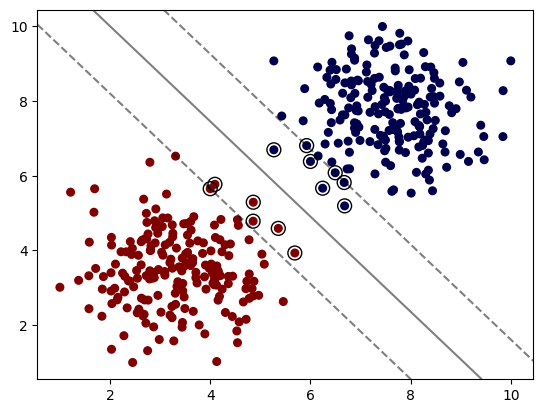

In [ ]:
model = SVC(kernel='poly', C=1,degree=1)
model.fit(X, y)
plot_svm_boundary(model,X,y)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


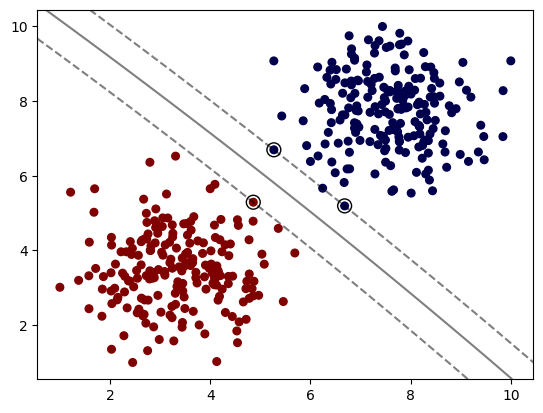

In [ ]:
model = SVC(kernel='poly', C=1,degree=2)
model.fit(X, y)
plot_svm_boundary(model,X,y)

### **gamma**

gamma : {'scale', 'auto'} or float, default='scale'
    Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.

    - if ``gamma='scale'`` (default) is passed then it uses
      1 / (n_features * X.var()) as value of gamma,
    - if 'auto', uses 1 / n_features.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


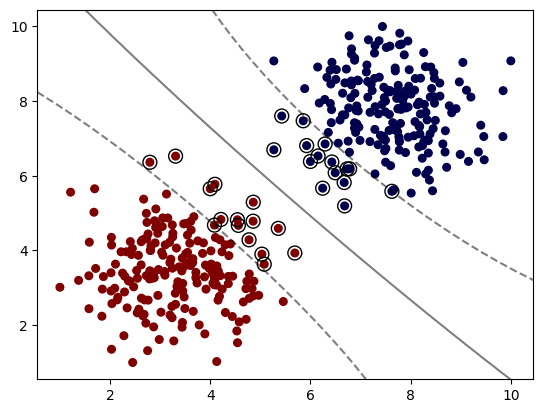

In [ ]:
model = SVC(kernel='rbf', C=1,gamma=0.01)
model.fit(X, y)
plot_svm_boundary(model,X,y)

### **How to choose the kernel?**
There is no single "correct" kernel for every dataset, but there is a standard rule of thumb based on the relationship between your number of features and number of samples.

**The General Rule of Thumb**

The choice typically depends on the dimensionality and size of your data:

- **Many Features, Few Samples:** Use a Linear kernel. In high-dimensional spaces (like text classification), data is often linearly separable already. Using a complex kernel here risks overfitting.

- **Few Features, Intermediate Samples:** Use the RBF kernel. It is the most flexible "all-rounder" and can capture complex, non-linear relationships when you have enough data to define them.

- **Few Features, Very Large Samples:** Avoid kernel SVMs entirely and use a linear learner (like LinearSVC or LogisticRegression). Kernel SVMs become extremely slow (complexity) as the sample size grows.



## **Grid Search**

Keep in mind, for this simple example, we saw the classes were easily separated, which means each variation of model could easily get 100% accuracy, meaning a grid search is "useless".

In [ ]:
from sklearn.model_selection import GridSearchCV

svm = SVC()
param_grid = {'C':[0.01,0.1,1],'kernel':['linear','rbf']}
grid = GridSearchCV(svm,param_grid)

In [ ]:
# Note again we didn't split Train|Test
grid.fit(X,y)

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.01, 0.1, 1], 'kernel': ['linear', 'rbf']})

In [ ]:
# 100% accuracy (as expected)
grid.best_score_

np.float64(1.0)

In [ ]:
grid.best_params_

{'C': 0.01, 'kernel': 'linear'}

This is more to review the grid search process, recall in a real situation such as your exercise, you will perform a train|test split and get final evaluation metrics.

<br><br><br><br><br>

Source: <a href='http://www.pieriandata.com'>www.pieriandata.com</a></em></center>


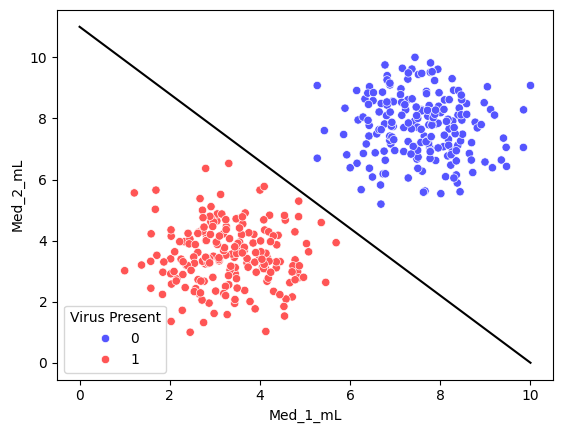

In [ ]:
sns.scatterplot(x='Med_1_mL',y='Med_2_mL',hue='Virus Present',palette='seismic',data=df)

x = np.linspace(0,10,100)
b0 = -1
b1 = 11
y = m*x + b
plt.plot(x,y,'k')

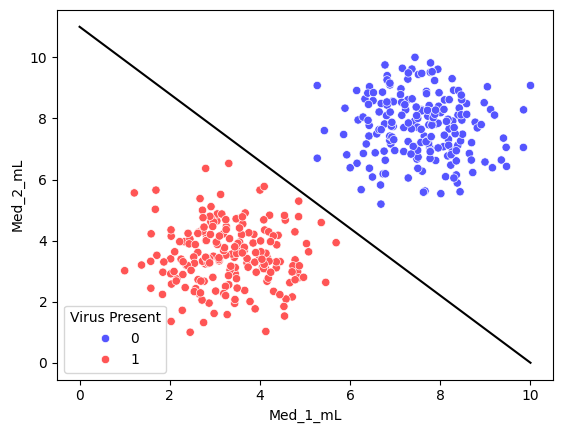

In [ ]:
sns.scatterplot(x='Med_1_mL',y='Med_2_mL',hue='Virus Present',palette='seismic',data=df)

x = np.linspace(0,10,100)
b0 = -10
b1 = 110
y = m*x + b
plt.plot(x,y,'k')